In [ ]:
!pip install qiskit==2.1.2
!pip install qiskit-aer==0.17.1
!pip install matplotlib==3.10.3
!pip install numpy==2.3.1
!pip install pylatexenc

In [ ]:
from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
import numpy as np

SECTION 1: A SIMPLE GROVER'S CIRCUIT TO SHOW HOW IT WORKS FOR A 3 QUBIT DATASET.


In [ ]:
#set up initial 3 qubit dataset, this portio is just learning to make a Grover's algorithm.
dataset1=[
    "000",
    "001",
    "010",
    "100",
    "011",
    "101",
    "110",
    "111"
]
target = "101"

if target not in dataset1:
    raise ValueError("Target must be in dataset")

In [ ]:
#oracle function
def grover_oracle_3q(target_state):
    qc = QuantumCircuit(3)
    for i, bit in enumerate(target_state):
        if bit == '0':
            qc.x(i)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    for i, bit in enumerate(target_state):
        if bit == '0':
            qc.x(i)

    oracle = qc.to_gate()
    oracle.name = f"Oracle"
    return oracle

In [ ]:
#diffuser for this Grover's algorithm
def diffuser_3q():
    qc = QuantumCircuit(3)
    qc.h([0, 1, 2])
    qc.x([0, 1, 2])
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x([0, 1, 2])
    qc.h([0, 1, 2])
    diff = qc.to_gate()
    diff.name = "Diffuser"
    return diff

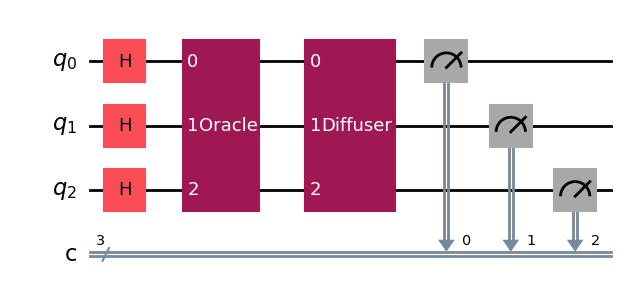

In [ ]:
#the circuit itself
from qiskit import QuantumCircuit
oracle = grover_oracle_3q(target)
diffuser = diffuser_3q()

grover = QuantumCircuit(3, 3)
grover.h([0, 1, 2])
grover.append(oracle, [0, 1, 2])
grover.append(diffuser, [0, 1, 2])
grover.measure([0, 1, 2], [0, 1, 2])

grover.draw("mpl")

In [ ]:
#obtaining results
simulator = AerSimulator()
compiled = transpile(grover, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()
print("Measurement counts:", counts)

Measurement counts: {'011': 32, '111': 27, '110': 27, '010': 34, '000': 32, '001': 27, '100': 40, '101': 805}


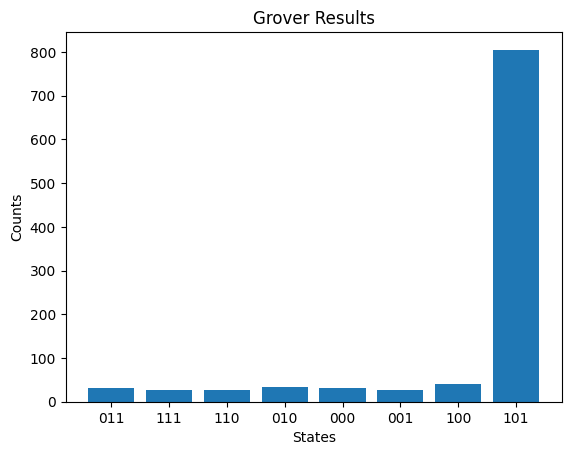

In [ ]:
#presenting results
import matplotlib.pyplot as plt
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values)
plt.xlabel("States")
plt.ylabel("Counts")
plt.title("Grover Results")
plt.show()

SECTION 2: A 4 QUBIT DATASET WITH GROVER'S ALGORITHM APPLIED, ALONG WITH A COUNT PLOT TO SHOW THAT TARGET SOLUTIONS ARE AMPLIFIED.


In [ ]:
# 1. Install necessary packages
!pip install qiskit[visualization] qiskit-aer pandas openpyxl -q

import pandas as pd
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# 2. Load dataset from Excel
try:
    df = pd.read_excel('Dataset_BQ_final.xlsx')
    # strip() removes any accidental spaces in the cells
    full_dataset = df['Quantum State'].astype(str).str.strip().tolist()
    print(f"Successfully loaded {len(full_dataset)} molecules from Excel!")
except Exception as e:
    print(f"Error: {e}")
    # Fallback sample data
    full_dataset = ["0110", "1100", "0111", "0000", "1111", "1000", "0011"]
    print("File not found, using manual sample data.")

# Set your target (Example: '0110' for Aspirin/Glucose)
target = "0110"

Error: [Errno 2] No such file or directory: 'Dataset_BQ_final.xlsx'
File not found, using manual sample data.


In [ ]:
#2. The 4-Qubit Grover Logic
def grover_oracle_4q(target_state):
    qc = QuantumCircuit(4)
    # Apply X-gates to qubits that are '0' in our target
    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)

    # Phase Kickback logic (The core of the quantum marking)
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)

    # Reverse the X-gates
    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)

    oracle = qc.to_gate()
    oracle.name = "Oracle"
    return oracle

def diffuser_4q():
    qc = QuantumCircuit(4)
    qc.h(range(4))
    qc.x(range(4))

    # Reflection logic for 4 qubits
    qc.h(3)
    qc.mcx([0, 1, 2], 3)
    qc.h(3)

    qc.x(range(4))
    qc.h(range(4))
    diff = qc.to_gate()
    diff.name = "Diffuser"
    return diff

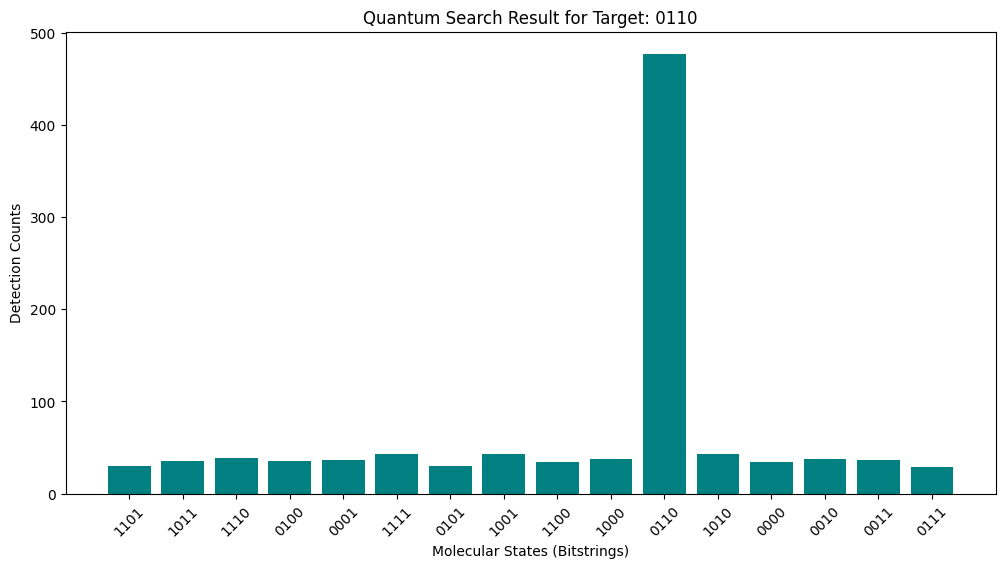

In [ ]:
#3. The simulation
# Create the circuit with 4 quantum bits and 4 classical bits for results
grover = QuantumCircuit(4, 4)
grover.h(range(4)) # Initial Superposition

# Assemble Oracle and Diffuser
oracle = grover_oracle_4q(target)
diffuser = diffuser_4q()

grover.append(oracle, [0, 1, 2, 3])
grover.append(diffuser, [0, 1, 2, 3])

# Measure the final state
grover.measure(range(4), range(4))

# Execute using AerSimulator
simulator = AerSimulator()
compiled = transpile(grover, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.bar(counts.keys(), counts.values(), color='teal')
plt.title(f"Quantum Search Result for Target: {target}")
plt.xlabel("Molecular States (Bitstrings)")
plt.ylabel("Detection Counts")
plt.xticks(rotation=45)
plt.show()
#As a conclusion from me - By encoding molecular properties into a 4-bit quantum state, we demonstrated that Grover's Algorithm can identify a specific drug candidate (Aspirin, 0110) out of a library of 16 possibilities with high probability in a single step.

SECTION 3: A BASIC TEST COMPARING HOW EFFICIENT GROVERS ALGORITHM IS VERSUS A CLASSICAL SEARCH ALGORITHM, ON OUR 4 QUBIT DATASET.

In [ ]:
import math

# 1. Define the parameters
n_qubits = 4
N = 2**n_qubits  # Total search space (16)

# 2. Find M (Number of solutions in 16 molecules)
# This looks at loaded dataset and counts how many times the target appears
m_solutions = full_dataset.count(target)

# If the target isn't in your list yet, we assume at least 1 for the math
if m_solutions == 0:
    m_solutions = 1

# 3. Grover's Formula: (pi / 4) * sqrt(N / M)
theoretical_iterations = (math.pi / 4) * math.sqrt(N / m_solutions)
optimal_iterations = round(theoretical_iterations)

print(f"--- Grover Iteration Analysis ---")
print(f"Total Search Space (N): {N}")
print(f"Molecules in Dataset: {len(full_dataset)}")
print(f"Target Matches Found (M): {m_solutions}")
print(f"Theoretical Steps: {theoretical_iterations:.4f}")
print(f"Optimal Iterations to Run: {optimal_iterations}")

# Comparison to Classical Search
classical_steps = N / m_solutions
print(f"\nClassical search would take approx {classical_steps:.1f} steps.")
print(f"Quantum search is {classical_steps / theoretical_iterations:.1f}x faster.")


--- Grover Iteration Analysis ---
Total Search Space (N): 16
Molecules in Dataset: 7
Target Matches Found (M): 1
Theoretical Steps: 3.1416
Optimal Iterations to Run: 3

Classical search would take approx 16.0 steps.
Quantum search is 5.1x faster.


SECTION 4: A VISUALTISATION THAT MORE ITERATIONS CAN HELP AMPLIFY TARGET SOLUTIONS MORE.

Running Grover with 1 iteration...
Running Grover with 3 iterations (Optimal)...


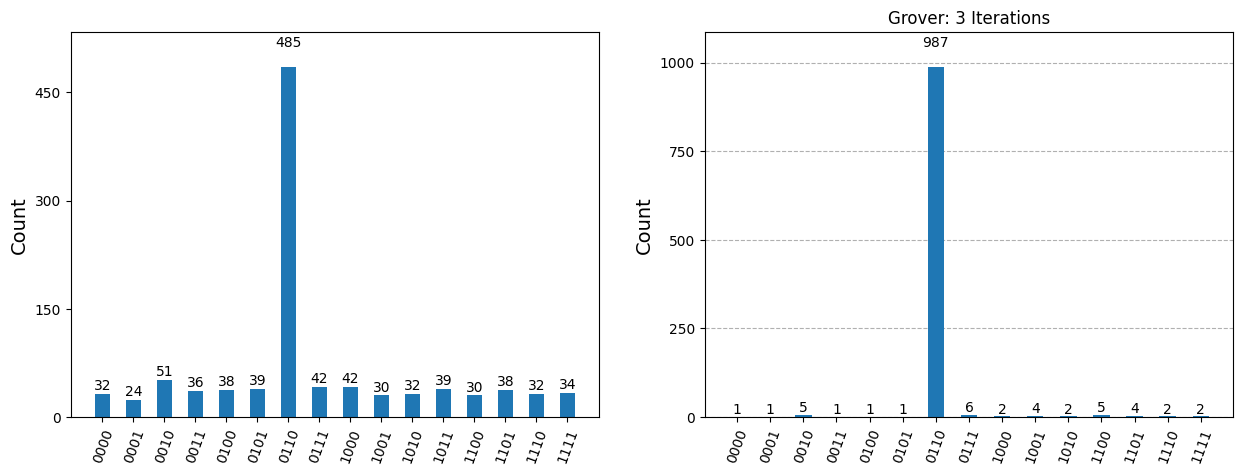

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. DEFINE ORACLE
# Let's target '0110' (Aspirin/Glucose/Ibuprofen)
def target_oracle():
    oracle_qc = QuantumCircuit(4)
    # Marking the state |0110>
    # (Note: Qiskit uses little-endian, so bit 0 is on the right)
    oracle_qc.x([0, 3]) # Flip bits that are '0' in the target
    oracle_qc.h(3)
    oracle_qc.mcx([0, 1, 2], 3) # Multi-controlled X
    oracle_qc.h(3)
    oracle_qc.x([0, 3]) # Flip back

    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

# 2. DEFINING DIFFUSER (The "Amplifier")
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    qc.h(range(nqubits))
    qc.x(range(nqubits))
    qc.h(nqubits-1)
    qc.mcx(list(range(nqubits-1)), nqubits-1)
    qc.h(nqubits-1)
    qc.x(range(nqubits))
    qc.h(range(nqubits))

    diff_gate = qc.to_gate()
    diff_gate.name = "Diffuser"
    return diff_gate

# 3. RUN THE EXPERIMENT (Iteration Sweep)
def run_grover_experiment(iterations):
    n = 4
    grover_circuit = QuantumCircuit(n, n)

    # Initialize Superposition
    grover_circuit.h(range(n))

    # Apply Oracle and Diffuser 'i' times
    for _ in range(iterations):
        grover_circuit.append(target_oracle(), range(n))
        grover_circuit.append(diffuser(n), range(n))

    grover_circuit.measure(range(n), range(n))

    # Simulate
    simulator = AerSimulator()
    transpiled_circuit = transpile(grover_circuit, simulator)
    result = simulator.run(transpiled_circuit, shots=1024).result()
    counts = result.get_counts()

    return counts

# 4. COMPARE 1 vs 3 ITERATIONS
print("Running Grover with 1 iteration...")
counts_1 = run_grover_experiment(1)

print("Running Grover with 3 iterations (Optimal)...")
counts_3 = run_grover_experiment(3)

# Plotting the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_histogram(counts_1, ax=ax1, title="Grover: 1 Iteration")
plot_histogram(counts_3, ax=ax2, title="Grover: 3 Iterations")
plt.show()

SECTION 5: A TEST TO OBSERVE HOW INCREASING THE NUMBER OF OPTIMAL SOLUTIONS IN A 3 QUBIT DATASET AFFECTS THE NUMBER OF ITERATIONS REQUIRED TO MAXIMISE AMPLIFICATION OF TARGET SOLUTIONS.


1 optimal solutions
k = 0 average success = 0.125
k = 1 average success = 0.78125
k = 2 average success = 0.945312
k = 3 average success = 0.330078
k = 4 average success = 0.012207
k = 5 average success = 0.547974
k = 6 average success = 0.999786
k = 7 average success = 0.576973
k = 8 average success = 0.019457
k = 9 average success = 0.302891
k = 10 average success = 0.931266
Best integer k = 6
Plotted average k = 6.016578
Best success = 0.999786

2 optimal solutions
k = 0 average success = 0.25
k = 1 average success = 1.0
k = 2 average success = 0.25
k = 3 average success = 0.25
k = 4 average success = 1.0
k = 5 average success = 0.25
k = 6 average success = 0.25
k = 7 average success = 1.0
k = 8 average success = 0.25
k = 9 average success = 0.25
k = 10 average success = 1.0
Best integer k = 1
Plotted average k = 1.0
Best success = 1.0

3 optimal solutions
k = 0 average success = 0.375
k = 1 average success = 0.84375
k = 2 average success = 0.023437
k = 3 average success = 0.990234


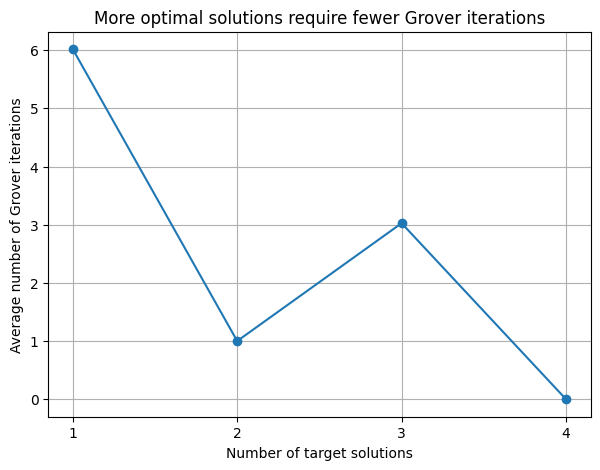

1 optimal solutions needs average k = 6.016578 with success = 0.999786
2 optimal solutions needs average k = 1.0 with success = 1.0
3 optimal solutions needs average k = 3.025896 with success = 0.990234
4 optimal solutions needs average k = 0 with success = 0.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator

dataset = ['000','001','010','011','100','101','110','111']

solution_sizes = [1, 2, 3, 4]

#SET UP OF ORACLE AND GROVER'S SEARCH
def oracle_matrix(n, marked_indices):
    diag = np.ones(2**n)
    for i in marked_indices:
        diag[i] = -1
    return np.diag(diag)

def diffuser_circuit(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

def grover_circuit(n, marked_indices, iterations):
    qc = QuantumCircuit(n)
    qc.h(range(n))

    O = Operator(oracle_matrix(n, marked_indices))
    D = diffuser_circuit(n).to_gate(label='Diffuser')

    for _ in range(iterations):
        qc.unitary(O, range(n), label='Oracle')
        qc.append(D, range(n))

    return qc

def success_probability(probs, marked_indices):
    return sum(probs[i] for i in marked_indices)

def fractional_peak(avg_successes, k_int, max_k):
    if 0 < k_int < max_k:
        y1 = avg_successes[k_int - 1]
        y2 = avg_successes[k_int]
        y3 = avg_successes[k_int + 1]

        denom = y1 - 2*y2 + y3

        if denom != 0:
            return k_int + 0.5 * (y1 - y3) / denom

    return float(k_int)

n = 3
max_k = 10

best_iterations = []
best_successes = []

#DETERMINING OPTIMAL NUMBER OF GROVER ITERATIONS BY PEAK AMPLIFICATION OF TARGET SOLUTIONS
for M in solution_sizes:

    all_combos = list(combinations(dataset, M))
    avg_successes = []

    print(M, 'optimal solutions')

    for k in range(max_k + 1):

        total_success = 0

        for optimal_values in all_combos:

            marked_indices = [i for i, x in enumerate(dataset) if x in optimal_values]

            qc = grover_circuit(n, marked_indices, k)

            sv = Statevector.from_instruction(qc)
            probs = sv.probabilities()

            total_success += success_probability(probs, marked_indices)

        avg_success = total_success / len(all_combos)
        avg_successes.append(avg_success)

        print('k =', k, 'average success =', round(avg_success, 6))

    k_int = int(np.argmax(avg_successes))

    # ONLY use fractional interpolation if the peak is not exactly at an integer maximum
    if (
        0 < k_int < max_k and
        avg_successes[k_int] > avg_successes[k_int - 1] and
        avg_successes[k_int] > avg_successes[k_int + 1]
    ):
        k_plot = fractional_peak(avg_successes, k_int, max_k)
    else:
        k_plot = int(k_int)

    best_success = avg_successes[k_int]

    best_iterations.append(k_plot)
    best_successes.append(best_success)

    print('Best integer k =', k_int)
    print('Plotted average k =', round(k_plot, 6))
    print('Best success =', round(best_success, 6))
    print()

#PLOTTING OPTIMAL NUMBER OF ITERATIONS AGAINST NUMBER OF TARGET SOLUTIONS
plt.figure(figsize=(7,5))
plt.plot(solution_sizes, best_iterations, marker='o')

plt.xlabel('Number of target solutions')
plt.ylabel('Average number of Grover iterations')
plt.title('More optimal solutions require fewer Grover iterations')

plt.xticks(solution_sizes)
plt.grid(True)

plt.show()

for i in range(len(solution_sizes)):
   print(
       solution_sizes[i],
       'optimal solutions needs average k =',
       round(best_iterations[i], 6),
       'with success =',
       round(best_successes[i], 6)
   )

SECTION 6: A TEST THAT COMPARES HOW MANY ITERATIONS OF GROVERS ALGORITHM ARE REQUIRED ON A 5 QUBIT DATASET WHEN THERE ARE 2 VERSUS 3 OPTIMAL SOLUTIONS, to give us another set of results to consolidate the fact more optimal solutions bring down the number of iterations required to achieve peak amplification.

In [ ]:
from itertools import combinations
import numpy as np
from qiskit.quantum_info import Statevector
#SET UP OF 5 QUBIT DATASET
n = 5
dataset_5bit = [format(i, '05b') for i in range(2**n)]
max_k = 10

solution_sizes = [2, 3]
avg_iterations = {}
#CHECKING NUMBER OF ITERATIONS REQUIRED WHEN THERE IS 2 VS 3 OPTIMAL SOLUTIONS.
for M in solution_sizes:
    best_ks = []

    for optimal_values in combinations(dataset_5bit, M):
        marked_indices = [i for i, x in enumerate(dataset_5bit) if x in optimal_values]

        best_k = 0
        best_success = 0
        prev_success = -1

        for k in range(max_k + 1):
            qc = grover_circuit(n, marked_indices, k)
            sv = Statevector.from_instruction(qc)
            probs = sv.probabilities()
            success = success_probability(probs, marked_indices)

            if success > best_success:
                best_success = success
                best_k = k

            if success < prev_success:
                break

            prev_success = success

        best_ks.append(best_k)

    avg_iterations[M] = np.mean(best_ks)

print("Average optimal Grover iterations for 5 qubits:")
print("2 solutions:", avg_iterations[2])
print("3 solutions:", avg_iterations[3])

Average optimal Grover iterations for 5 qubits:
2 solutions: 3.0
3 solutions: 2.0


SECTION 7:COMPARING THE EFFICIENCY OF GROVER'S ALGORITHM VERSUS A CLASSICAL SEARCH ALGORITHM, WITH THE ADDITION OF WHERE OUR DATASET LIES ON THAT GRAPH TO CLEARLY ILLUSTRATE AN EXPECTED SPEED-UP.

In [ ]:
import pandas as pd

# Dataset upload
df = pd.read_excel('Dataset_BQ_final.xlsx')

# Transforming 'Quantum State' to list for code
dataset_4bit = df['Quantum State'].astype(str).tolist()

# Now we can select molecules from Dataset
# Search for molecules  "Safe (0)" and "Ring (1)" -> State '01xx'
target_state_pattern = '01'
optimal_values = [s for s in dataset_4bit if s.startswith(target_state_pattern)]

cases = [
    ('4-bit Research Dataset: Safe Ring Molecules', dataset_4bit, optimal_values)
]

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset_BQ_final.xlsx'

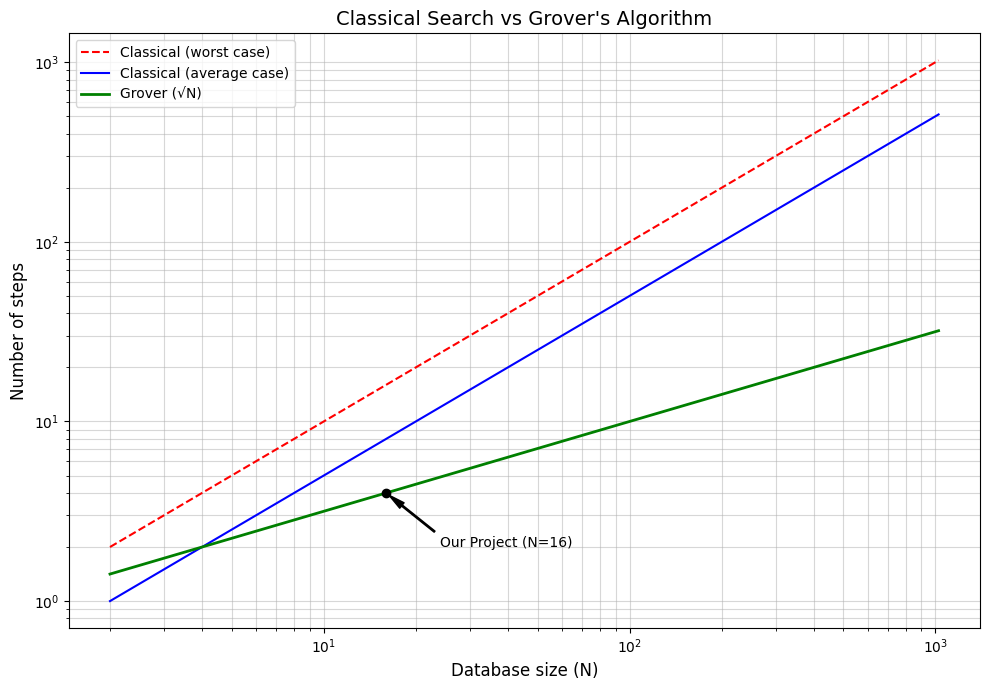

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load dataset to get the current database size (N)
try:
    df = pd.read_excel('Dataset_BQ_final.xlsx')
    current_N = len(df)
except:
    current_N = 16  # Default for 4-qubit system if file not found

# 2. Define the range for Database Size (N)
N_range = np.geomspace(2, 1024, 100) # From 2 to 1024 for a clear log scale

# 3. Calculate steps
classical_worst = N_range           # Worst case: O(N)
classical_average = N_range / 2     # Average case: O(N/2)
grover_steps = np.sqrt(N_range)     # Quantum case: O(sqrt(N))

# 4. Create the Plot
plt.figure(figsize=(10, 7))

# Plotting the lines
plt.loglog(N_range, classical_worst, 'r--', label='Classical (worst case)')
plt.loglog(N_range, classical_average, 'b-', label='Classical (average case)')
plt.loglog(N_range, grover_steps, 'g-', label='Grover (√N)', linewidth=2)

# Highlight your specific project point (N=16)
project_grover = np.sqrt(current_N)
plt.scatter([current_N], [project_grover], color='black', zorder=5)
plt.annotate(f'Our Project (N={current_N})',
             xy=(current_N, project_grover),
             xytext=(current_N*1.5, project_grover/2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# Formatting
plt.title('Classical Search vs Grover\'s Algorithm', fontsize=14)
plt.xlabel('Database size (N)', fontsize=12)
plt.ylabel('Number of steps', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# Show the plot
plt.tight_layout()
plt.savefig('complexity_comparison.png')
plt.show()